In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
DATA_PATH = "E:/ML/UBC"

In [4]:
with open(os.path.join(DATA_PATH,"./FeatureData.pkl"), "rb") as f:
    zippedData = pickle.load(f)
    X,y = zip(*zippedData)

In [9]:
X = np.array(X)
y = np.array(y)
print(X.shape)
print(y.shape)

(819, 512)
(819,)


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
y_train.shape

(548,)

In [11]:
from sklearn.ensemble import HistGradientBoostingClassifier
clf = HistGradientBoostingClassifier().fit(X_train, y_train)
clf.score(X_train, y_train)

1.0

In [12]:
clf.score(X_test, y_test)

0.955719557195572

In [13]:
with open(os.path.join(DATA_PATH,"./FeatureClassifier.pkl"), "wb") as f:
    pickle.dump(clf, f)

## t-SNE

In [47]:
from sklearn.manifold import TSNE

X_embedded = TSNE(n_components=2, perplexity=40).fit_transform(X)
print(X_embedded.shape)

(819, 2)


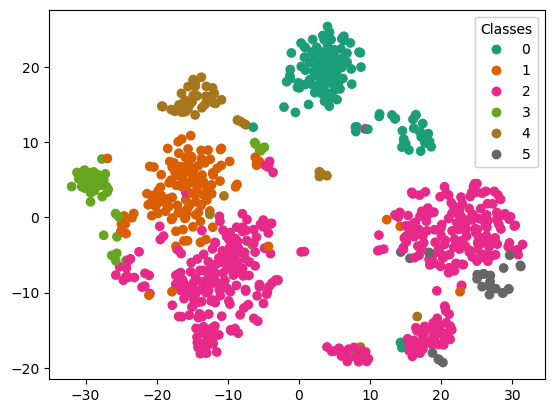

In [48]:
fig, ax = plt.subplots()

scatter = ax.scatter(X_embedded[:,0], X_embedded[:,1], c=y, cmap="Dark2")

# produce a legend with the unique colors from the scatter
legend1 = ax.legend(*scatter.legend_elements(), title="Classes")
ax.add_artist(legend1)

handles, labels = scatter.legend_elements(prop="sizes", alpha=0.6)

# plt.colorbar()